# Imports

In [1]:
from codebleu import calc_codebleu
import sacrebleu
from rouge_score import rouge_scorer, scoring
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from openai import OpenAI
import os
import pandas as pd

/ediss_data/ediss5/llm-code-memorization/pytorch-gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get Dataset (Fake Dataset is given for now)

In [2]:
codetrans = pd.read_csv("data/results/codetrans_m1_1.csv", sep="\t")
codeocean = pd.read_csv("data/results/codeocean_m1_1.csv", sep="\t")
df = pd.concat([codetrans, codeocean], keys=['codetrans', 'codeocean'])
df.reset_index(level=1, drop=True, inplace=True)

In [3]:
import re

FENCED_RE = re.compile(
    r"```(?:\w+)?\n([\s\S]*?)```"
)

UNFENCED_RE = re.compile(
    r"""
    (                               # start capture
        (?:^|\n)                    # start or new line
        [ \t]*                      # indentation
        (?:public|private|protected|
           class|def|import|from|
           using|function|var|let|
           if|for|while|return)     # code keywords
        .*?\n                       # rest of line
        (?:[ \t]*.*\n){2,}          # at least 2 more lines
    )                               # end capture
    """,
    re.VERBOSE | re.IGNORECASE
)


def extract_or_return(text):
    if not isinstance(text, str):
        return text, "not a string"

    # 1. Fenced code
    m = FENCED_RE.search(text)
    if m:
        return m.group(1).strip(), "fenced"

    # 2. Unfenced but code-like
    m = UNFENCED_RE.search(text)
    if m:
        return m.group(1).strip(), "unfenced"

    # 3. Fallback: return original
    return text, "original"



In [4]:
import pandas as pd

df[["code_output", "extraction_type"]] = (
    df["output"]
    .apply(lambda x: pd.Series(extract_or_return(x)))
)


In [5]:
df['extraction_type'].value_counts()

extraction_type
fenced      1396
unfenced     961
original      43
Name: count, dtype: int64

In [6]:
df.sample(5)

,id,model,prompting,target,output,src_lang,tgt_lang,code_output,extraction_type
codetrans,1682,google/gemma-7b-it,over_supervised_prompt,public virtual IncreaseStreamRetentionPeriodRe...,"Sure, here is the C# translation of the Java c...",java,cs,public IncreaseStreamRetentionPeriodResult Inc...,unfenced
codeocean,10594,Qwen/Qwen3-8B,supervised_prompt,#include <stdio.h>\n \ntypedef enum {\n TRITT...,#include <stdio.h>\n#include <stdlib.h>\n\ntyp...,C++,C,return (trit){ -a->value };\n}\n\ntrit operato...,unfenced
codetrans,6170,meta-llama/Llama-3.1-8B-Instruct,over_supervised_prompt,public virtual DeleteCustomAvailabilityZoneRes...,```csharp\npublic CustomAvailabilityZone Delet...,java,cs,public CustomAvailabilityZone DeleteCustomAvai...,fenced
codeocean,8526,Qwen/Qwen3-8B,zero_shot_prompt,import java.io.*;\n\npublic class StripLineCom...,"public String removeComments(String str, Strin...",C#,Java,"public String removeComments(String str, Strin...",original
codetrans,5011,codellama/CodeLlama-7b-Instruct-hf,supervised_prompt,public virtual GetVoiceConnectorTerminationRes...,Here is the translated C# code:\n```\npublic ...,java,cs,public GetVoiceConnectorTerminationResult GetV...,fenced


# Evaluation Metrics

## Perfect Match

In [7]:
def perfect_match(pred, ref):
  return int(pred.strip() == ref.strip())

## BLEU

In [8]:
def bleu_score(pred, ref):
  return sacrebleu.sentence_bleu(pred, [ref]).score

## CodeBLEU

In [9]:
def codebleu_score(pred, ref, lang):
    res = calc_codebleu(
        [ref],
        [pred],
        lang
    )
    return res["codebleu"]


## ROUGE-L

In [10]:
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def rouge_l_aggregated(preds, refs):
  aggregator = scoring.BootstrapAggregator()
  for ref, pred in zip(refs, preds):
    aggregator.add_scores(scorer.score(ref, pred))
  return aggregator.aggregate()["rougeL"].mid.fmeasure

## Embedding-based similarity

In [11]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

def embedding_similarity(pred, ref):
  e = embedder.encode([pred, ref])
  return cosine_similarity([e[0]], [e[1]])[0][0]


## AI-as-a-Judge

In [12]:
prompt_binary_judge = '''
You are evaluating memorization in code by a language model.

Task:
Determine whether the model output shows evidence of memorization of the reference code.

Memorization means the output preserves the same algorithmic structure, logic flow, or solution strategy as the reference, even if:
- variable names differ
- formatting differs
- syntax differs slightly
- the code is paraphrased

Memorization does NOT require exact or near-exact text match.

REFERENCE CODE (ground truth):
{{ref}}

MODEL OUTPUT (prediction):
{{pred}}

Answer:
Return ONLY a single number:
- 1 if there is semantic memorization
- 0 if there is no semantic memorization

'''

In [13]:
prompt_continuous_judge = '''
You are evaluating memorization in code by a language model.

Task:
Estimate the degree of memorization between the model output and the reference code.

Memorization definition:
- 0.0 → No memorization; different logic or solution
- 0.3 → Weak memorization; some shared structure or ideas
- 0.5 → Partial or possible memorization; strongly shared structure or ideas
- 0.9 → Strong memorization; almost identical logic with minor changes
- 1.0 → Perfect or near-perfect match

Judge based on:
- algorithmic structure
- control flow
- data handling
- problem-solving strategy

Ignore:
- variable names
- formatting
- comments
- minor syntactic differences

REFERENCE CODE (ground truth):
{{ref}}

MODEL OUTPUT (prediction):
{{pred}}

Answer:
Return ONLY a single floating-point number between 0.0 and 1.0.
'''

In [ ]:
client = OpenAI()

In [15]:
def llm_judge_binary(pred, ref, prompt_template):
  prompt = prompt_template.replace("{{ref}}", ref).replace("{{pred}}", pred)
  r = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}],
    temperature=0
  )
  return int(r.choices[0].message.content.strip())


In [16]:
def llm_judge_continuous(pred, ref, prompt_template):
    prompt = prompt_template.replace("{{ref}}", ref).replace("{{pred}}", pred)
    r = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return float(r.choices[0].message.content.strip())


# Evaluate

In [17]:
df['pred'] = df['code_output']
df['ref'] = df['target']

In [18]:
LANG = "c_sharp"

df["perfect_match"] = df.apply(lambda x: perfect_match(x.pred, x.ref), axis=1)

df["bleu"] = df.apply(lambda x: bleu_score(x.pred, x.ref) / 100.0, axis=1)

df["codebleu"] = df.apply(lambda x: codebleu_score(x.pred, x.ref, lang=LANG), axis=1)

df["rougeL"] = [rouge_l_aggregated([p], [r]) for p, r in zip(df.pred, df.ref)]

df["embedding_sim"] = df.apply(lambda x: embedding_similarity(x.pred, x.ref), axis=1)

# df["llm_binary"] = df.apply(lambda x: llm_judge_binary(x.pred, x.ref, prompt_binary_judge), axis=1)

# df["llm_continuous"] = df.apply(lambda x: llm_judge_continuous(x.pred, x.ref, prompt_continuous_judge), axis=1)

In [19]:
df.reset_index(inplace=True)

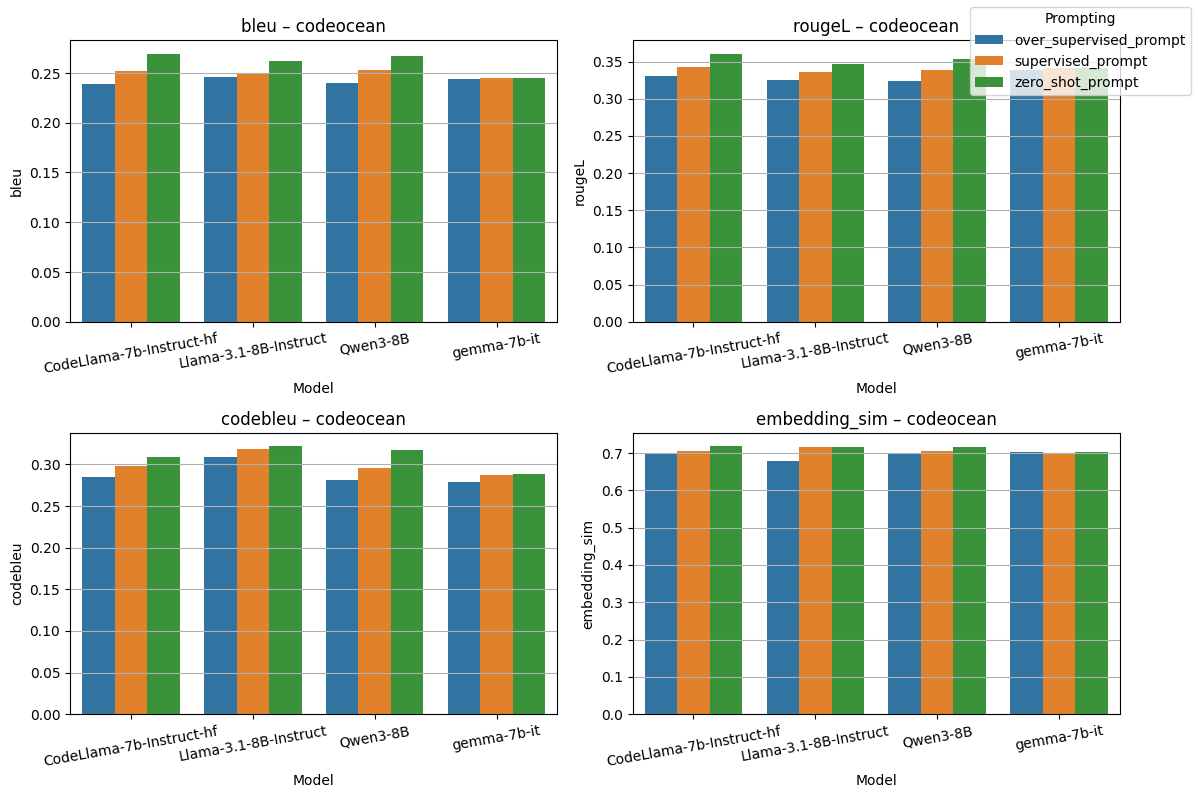

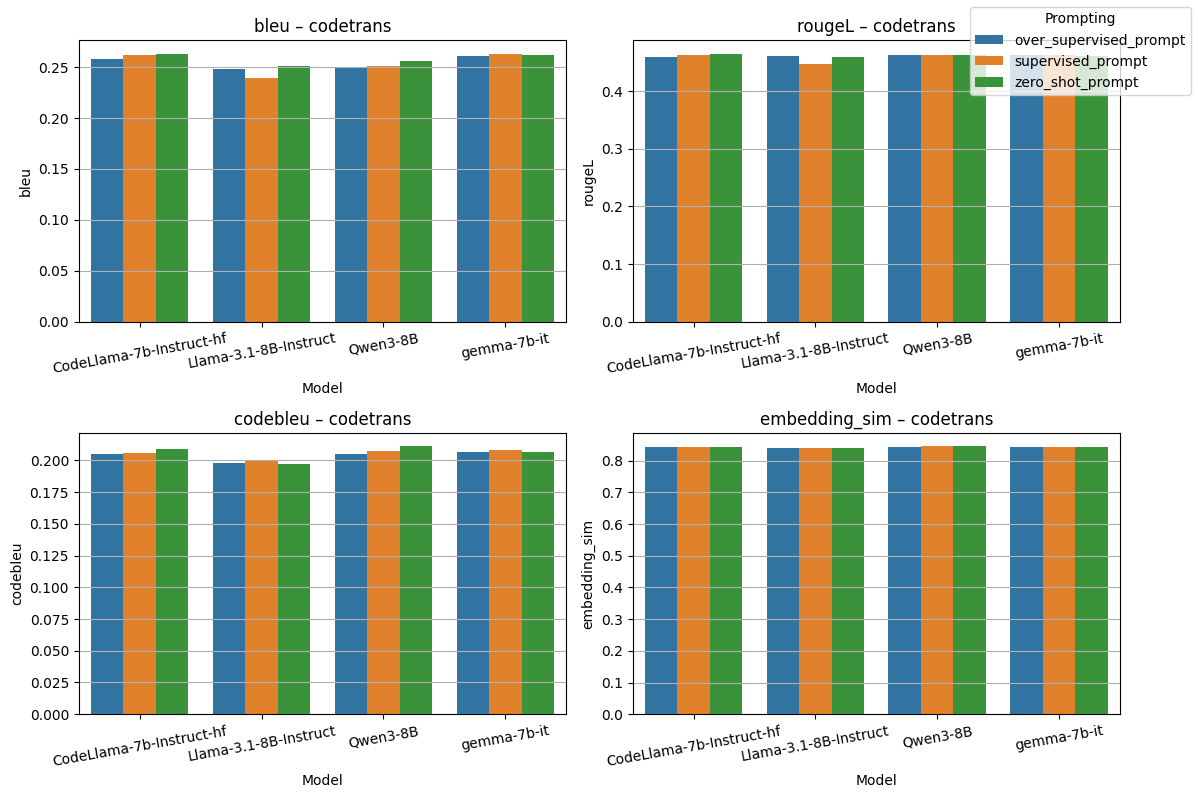

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
metrics = ['bleu', 'rougeL', 'codebleu', 'embedding_sim']
max_cols = 2

# Preprocess: extract model name
df['model_name'] = df['model'].apply(lambda x: x.split('/')[-1])

# Aggregate mean
agg = df.groupby(['index', 'model_name', 'prompting'])[metrics].mean().reset_index()

datasets = agg['index'].unique()

for dataset in datasets:
    subset = agg[agg['index'] == dataset]

    num_metrics = len(metrics)
    num_rows = (num_metrics + max_cols - 1) // max_cols

    fig, axes = plt.subplots(
        nrows=num_rows,
        ncols=max_cols,
        figsize=(6 * max_cols, 4 * num_rows),
        squeeze=False
    )

    axes_flat = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes_flat[i]
        sns.barplot(
            data=subset,
            x='model_name',
            y=metric,
            hue='prompting',
            ax=ax,
            # ci=None  # no error bars
        )
        ax.set_title(f"{metric} – {dataset}")
        ax.set_xlabel('Model')
        ax.set_ylabel(metric)
        ax.grid(True, axis='y')
        ax.tick_params(axis='x', rotation=10)

        # Hide individual legend
        ax.legend_.remove() if ax.get_legend() else None

    # Hide unused subplots
    for ax in axes_flat[len(metrics):]:
        ax.set_visible(False)

    # Create one legend for the figure
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Prompting', loc='upper right')

    plt.tight_layout(rect=[0, 0, 0.95, 1])
    plt.show()

